In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]

In [3]:
df_adult = pd.read_csv(
    "adult.data", names=columns, sep=",", skipinitialspace=True
)

print("--- Initial Dataset Snapshot ---")
print(f"Dataset Shape: {df_adult.shape}")
print(df_adult.head(3))

--- Initial Dataset Snapshot ---
Dataset Shape: (32561, 15)
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital_status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  <=50K  


In [4]:
df_adult.replace("?", np.nan, inplace=True)
print("Missing values per column before cleaning:")
print(df_adult.isnull().sum()[df_adult.isnull().sum() > 0])


Missing values per column before cleaning:
workclass         1836
occupation        1843
native_country     583
dtype: int64


In [5]:
cat_cols_with_nan = ["workclass", "occupation", "native_country"]
imputer = SimpleImputer(strategy="most_frequent")
df_adult[cat_cols_with_nan] = imputer.fit_transform(
    df_adult[cat_cols_with_nan]
)


In [6]:
median_gain = df_adult["capital_gain"].median()
gain_zscore = np.abs(zscore(df_adult["capital_gain"]))
df_adult["capital_gain"] = np.where(
    gain_zscore > 3, median_gain, df_adult["capital_gain"]
)

print("\n✔ Data Cleaning Completed (Missing values imputed & outliers capped).")


✔ Data Cleaning Completed (Missing values imputed & outliers capped).


In [7]:
duplicate_count = df_adult.duplicated().sum()
print(f"Number of duplicate rows found and removed: {duplicate_count}")
df_integrated = df_adult.drop_duplicates().reset_index(drop=True)
print("✔ Data Integration / Deduplication Completed.")

Number of duplicate rows found and removed: 24
✔ Data Integration / Deduplication Completed.


In [8]:
df_transformed = df_integrated.copy()
scaler_minmax = MinMaxScaler()
df_transformed["hours_per_week_scaled"] = scaler_minmax.fit_transform(
    df_transformed[["hours_per_week"]]
)

In [9]:
scaler_minmax = MinMaxScaler()
df_transformed["hours_per_week_scaled"] = scaler_minmax.fit_transform(
    df_transformed[["hours_per_week"]]
)

In [10]:
scaler_std = StandardScaler()
df_transformed[["age_scaled", "capital_gain_scaled"]] = (
    scaler_std.fit_transform(df_transformed[["age", "capital_gain"]])
)

In [11]:
le = LabelEncoder()
df_transformed["income_label"] = le.fit_transform(df_transformed["income"])


In [12]:
categorical_columns = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country",
]
for col in categorical_columns:
    df_transformed[f"{col}_encoded"] = le.fit_transform(df_transformed[col])

print("--- Transformed Sub-DataFrame Sample ---")
print(
    df_transformed[
        ["age_scaled", "hours_per_week_scaled", "income_label"]
    ].head()
)

--- Transformed Sub-DataFrame Sample ---
   age_scaled  hours_per_week_scaled  income_label
0    0.030390               0.397959             0
1    0.836973               0.122449             0
2   -0.042936               0.397959             0
3    1.056950               0.397959             0
4   -0.776193               0.397959             0


In [13]:
encoded_features = [f"{col}_encoded" for col in categorical_columns] + [
    "age_scaled",
    "capital_gain_scaled",
    "hours_per_week_scaled",
    "education_num",
]
X = df_transformed[encoded_features]
y = df_transformed["income_label"]

In [14]:
selector = SelectKBest(score_func=f_classif, k=4)
X_selected = selector.fit_transform(X, y)
selected_indices = selector.get_support(indices=True)
print("--- Feature Selection ---")
print(
    f"Top 4 Native Features: {np.array(encoded_features)[selected_indices].tolist()}"
)

--- Feature Selection ---
Top 4 Native Features: ['relationship_encoded', 'age_scaled', 'capital_gain_scaled', 'education_num']


In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("\n--- PCA Reduction ---")
print(f"Original Feature Shape: {X.shape} -> PCA Matrix Shape: {X_pca.shape}")



--- PCA Reduction ---
Original Feature Shape: (32537, 12) -> PCA Matrix Shape: (32537, 2)


In [16]:
df_sample = df_transformed.sample(frac=0.05, random_state=42)
X_pca_sample = pca.transform(df_sample[encoded_features])
y_sample = df_sample["income_label"].values

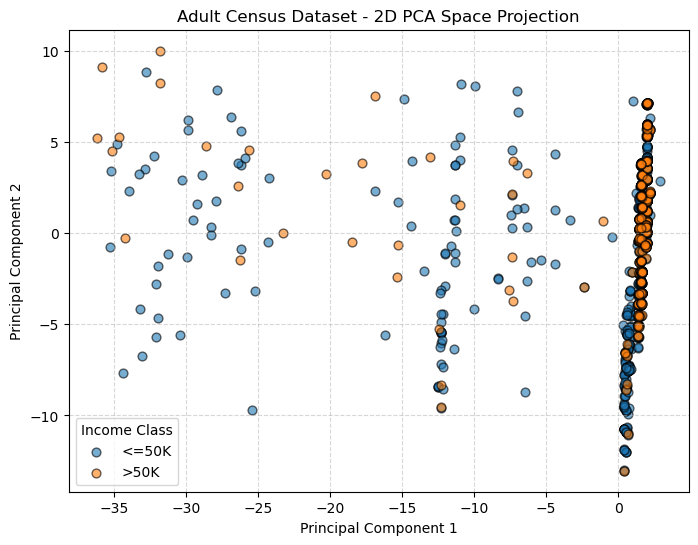

In [17]:
plt.figure(figsize=(8, 6))
for label_val, label_name, color in zip(
    [0, 1], ["<=50K", ">50K"], ["#1f77b4", "#ff7f0e"]
):
    mask = y_sample == label_val
    plt.scatter(
        X_pca_sample[mask, 0],
        X_pca_sample[mask, 1],
        label=label_name,
        alpha=0.6,
        edgecolor="k",
        s=40,
        c=color,
    )

plt.title("Adult Census Dataset - 2D PCA Space Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Income Class")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()